# Customer cohorts, lifetime value and segments

**Question:** how much is a customer worth over time, do they come back, and which groups matter most?

Data: Olist Brazilian E-commerce, ~98K non-cancelled orders from ~95K real customers (2016-2018).
Customers are identified by `customer_unique_id`, because the source issues a new `customer_id` for every order.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.plotting import BLUE, INK, INK_2, ORANGE, clean, save, title

con = duckdb.connect("../data/processed/olist.duckdb", read_only=True)
customers = con.sql("select * from customers").df()
cohorts = con.sql("select * from cohort_retention").df()
orders = con.sql("select * from orders").df()
print(f"{len(orders):,} orders · {len(customers):,} customers · "
      f"{orders.purchased_at.min():%b %Y} to {orders.purchased_at.max():%b %Y}")

98,199 orders · 94,983 customers · Sep 2016 to Sep 2018


## 1. Headline numbers

In [2]:
repeat_rate = (customers.frequency > 1).mean()
headline = pd.Series({
    "Customers": f"{len(customers):,}",
    "Avg order value (BRL)": f"{orders.order_value.mean():.2f}",
    "Avg revenue per customer (BRL)": f"{customers.monetary.mean():.2f}",
    "Customers who ever bought twice": f"{repeat_rate:.1%}",
    "Revenue from repeat customers": f"{customers.loc[customers.frequency > 1, 'monetary'].sum() / customers.monetary.sum():.1%}",
})
headline.to_frame("value")

,value
Customers,"94,983"
Avg order value (BRL),160.24
Avg revenue per customer (BRL),165.67
Customers who ever bought twice,3.0%
Revenue from repeat customers,5.7%


## 2. Cohort retention
Each row is the month a customer first bought. Each column is months since then. Cells show the share of the cohort that bought again in that month.
Only complete cohorts (Jan 2017 - Jun 2018) are shown.

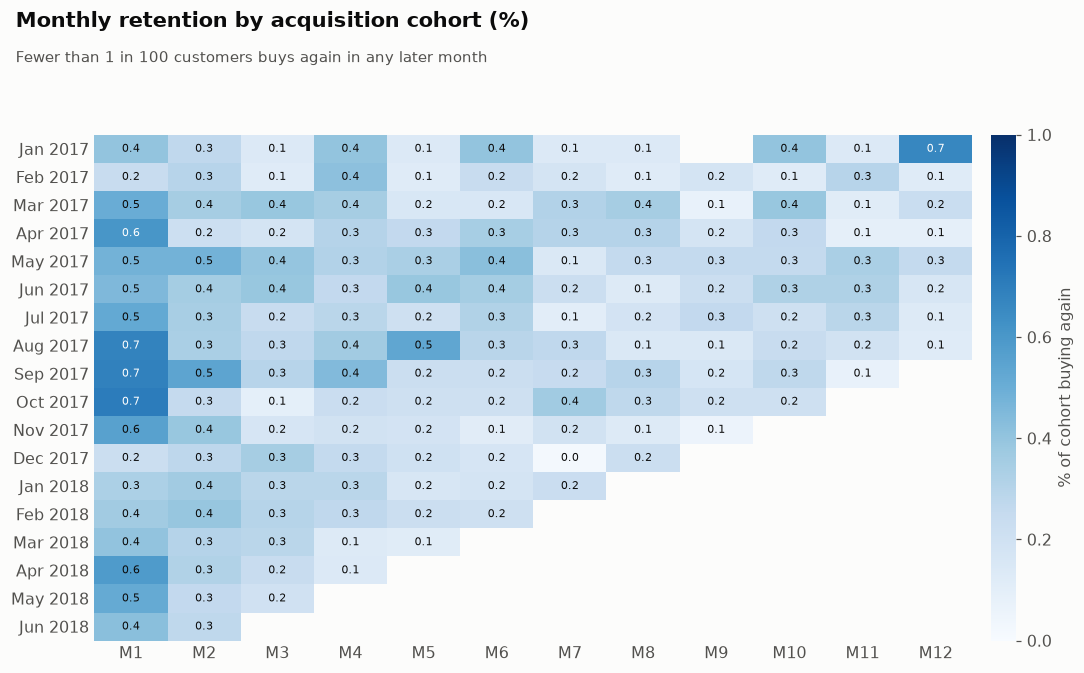

In [3]:
c = cohorts[(cohorts.cohort_month >= "2017-01-01") & (cohorts.cohort_month <= "2018-06-01")]
heat = c.pivot(index="cohort_month", columns="months_since_first", values="retention_rate")
heat = heat.loc[:, 1:12]  # month 0 is always 100%
heat.index = pd.to_datetime(heat.index).strftime("%b %Y")

fig, ax = plt.subplots(figsize=(10, 6.2))
im = ax.imshow(heat.values * 100, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(heat.shape[1]), [f"M{m}" for m in heat.columns])
ax.set_yticks(range(heat.shape[0]), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v * 100:.1f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v * 100 > 0.6 else INK)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("% of cohort buying again")
cb.outline.set_visible(False)
title(fig, "Monthly retention by acquisition cohort (%)",
      "Fewer than 1 in 100 customers buys again in any later month")
save(fig, "cohort_retention.png")
plt.show()

## 3. Lifetime value curve
Average cumulative revenue per customer, by months since first purchase (Jan-Jun 2017 cohorts, which have 12+ months of history).

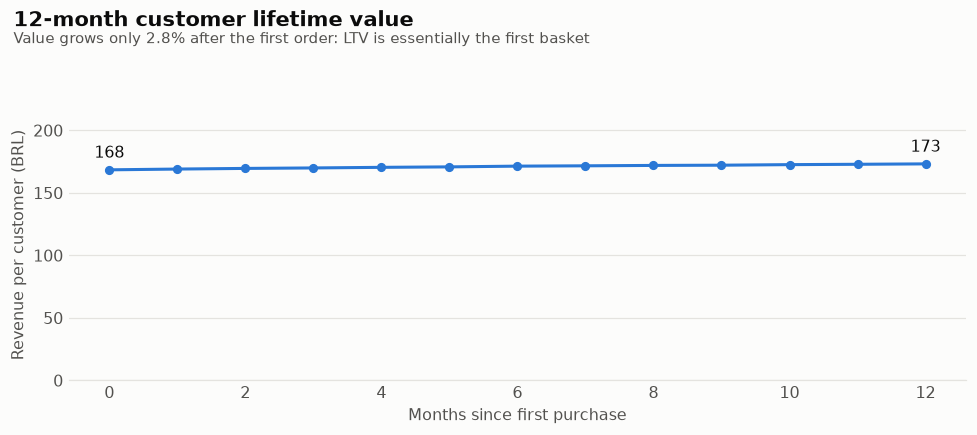

LTV month 0: 168.47 BRL · month 12: 173.23 BRL · uplift 2.8%


In [4]:
mature = cohorts[(cohorts.cohort_month >= "2017-01-01") & (cohorts.cohort_month <= "2017-06-01")]
curve = (mature[mature.months_since_first <= 12]
         .pivot(index="months_since_first", columns="cohort_month", values="cumulative_revenue_per_customer")
         .ffill().mean(axis=1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curve.index, curve.values, color=BLUE, linewidth=2, marker="o", markersize=5)
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Revenue per customer (BRL)")
ax.set_ylim(0, curve.max() * 1.25)
for m in (0, 12):
    ax.annotate(f"{curve[m]:.0f}", (m, curve[m]), xytext=(0, 8), textcoords="offset points", ha="center", color=INK)
clean(ax)
uplift = curve[12] / curve[0] - 1
title(fig, "12-month customer lifetime value",
      f"Value grows only {uplift:.1%} after the first order: LTV is essentially the first basket")
save(fig, "ltv_curve.png")
plt.show()
print(f"LTV month 0: {curve[0]:.2f} BRL · month 12: {curve[12]:.2f} BRL · uplift {uplift:.1%}")

## 4. RFM segments
Recency (days since last order) and Monetary (total spend) are scored in quartiles. Frequency is almost always 1 here, so it's used as a simple repeat/non-repeat split.

| Segment | Rule |
|---|---|
| Champions | bought 2+ times, recently |
| Loyal, lapsing | bought 2+ times, not recently |
| New high-value | one order, recent, top-25% spend |
| New, low-value | one order, recent |
| Lost high-value | one order, long ago, top-25% spend |
| Lost low-value | one order, long ago |

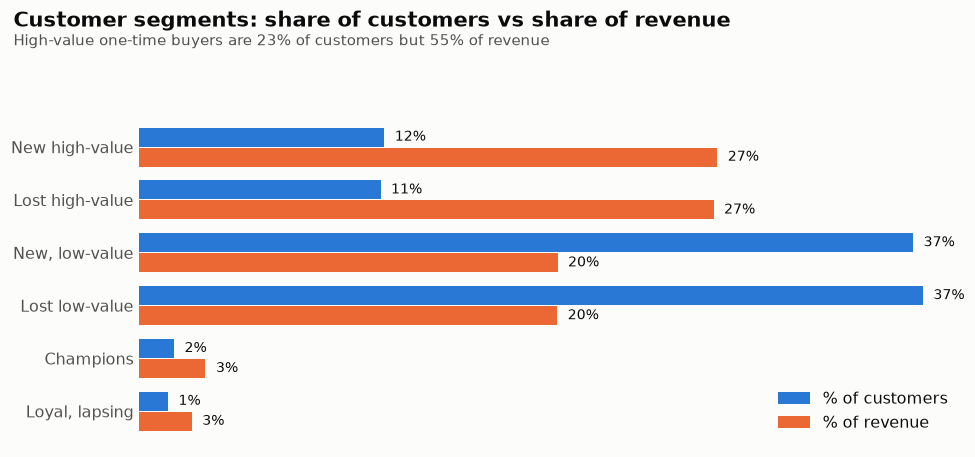

,customers,revenue,avg_spend,avg_recency_days,pct_customers,pct_revenue
segment,,,,,,
New high-value,11048,4314864.12,390.56,117.69,0.12,0.27
Lost high-value,10880,4286911.17,394.02,372.74,0.11,0.27
"New, low-value",34863,3123116.87,89.58,117.87,0.37,0.20
Lost low-value,35305,3120419.66,88.38,370.65,0.37,0.20
Champions,1580,496490.35,314.23,118.15,0.02,0.03
"Loyal, lapsing",1307,393724.86,301.24,359.58,0.01,0.03


In [5]:
seg = (customers.groupby("segment")
       .agg(customers=("customer_unique_id", "count"), revenue=("monetary", "sum"),
            avg_spend=("monetary", "mean"), avg_recency_days=("recency_days", "mean"))
       .assign(pct_customers=lambda d: d.customers / d.customers.sum(),
               pct_revenue=lambda d: d.revenue / d.revenue.sum())
       .sort_values("revenue", ascending=True))

fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(seg))
ax.barh(y + 0.19, seg.pct_customers * 100, height=0.36, color=BLUE, label="% of customers")
ax.barh(y - 0.19, seg.pct_revenue * 100, height=0.36, color=ORANGE, label="% of revenue")
ax.set_yticks(y, seg.index)
for i, (pc, pr) in enumerate(zip(seg.pct_customers, seg.pct_revenue)):
    ax.text(pc * 100 + 0.5, i + 0.19, f"{pc:.0%}", va="center", fontsize=9, color=INK)
    ax.text(pr * 100 + 0.5, i - 0.19, f"{pr:.0%}", va="center", fontsize=9, color=INK)
ax.xaxis.set_visible(False)
clean(ax, grid_axis=None)
ax.spines["bottom"].set_visible(False)
ax.legend(loc="lower right", frameon=False)
top = seg.loc[["New high-value", "Lost high-value"]]
title(fig, "Customer segments: share of customers vs share of revenue",
      f"High-value one-time buyers are {top.pct_customers.sum():.0%} of customers but {top.pct_revenue.sum():.0%} of revenue")
save(fig, "segments.png")
plt.show()
seg.sort_values("revenue", ascending=False).round(2)

## What this means for the business

1. **This is a one-purchase business.** Under 3% of customers ever buy twice, and 12-month value is barely above the first basket. Growth depends on paid acquisition, so **CAC must stay below first-order margin**. Payback can't be counted on from repeat purchases.
2. **The biggest lever is the second order.** Even moving the repeat rate from ~3% to 5% would be a large lift in revenue per customer, at almost no acquisition cost. A post-delivery win-back flow (a voucher 30-60 days after the first delivery) is the obvious test.
3. **Target the "New high-value" segment first.** They're recent, they spend 4x the average, and there's still time to bring them back before they become "Lost high-value".
4. **Protect the first experience.** The companion analysis in the modern-data-stack project shows late deliveries get 1-2 star reviews 79% of the time. With almost no second chances, the first order is the whole relationship.